In [1]:
pip install vaderSentiment

In [2]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [4]:
data = pd.read_csv('amazon_alexa.tsv', sep='\t')
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [5]:
data.shape

(3150, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [7]:
data.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [8]:
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [9]:
# handling missing values
data['verified_reviews'].fillna("", inplace=True)

C:\Users\Prachi\AppData\Local\Temp\ipykernel_1848\348515712.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['verified_reviews'].fillna("", inplace=True)


In [10]:
#initialize VADER sentiment analyzer
sentiment_analyzer = SentimentIntensityAnalyzer() 

In [11]:
# data cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]","", text)
    return text

data['cleaned_reviews'] = data['verified_reviews'].apply(clean_text)

In [12]:
# get sentiment score
def get_sentiment(text):
    scores = sentiment_analyzer.polarity_scores(text)
    return scores['compound']

In [ ]:
# get sentiment score
# def get_sentiment(text):
#     scores = sentiment_analyzer.polarity_scores(text)
#     if scores['compound'] >= 0.05:
#         return 1  # Positive
#     elif scores['compound'] <= -0.05:
#         return 0  # Negative
#     else:
#         return 2  # Neutral

In [13]:
# apply sentiment analysis
data['sentiment_score'] = data['cleaned_reviews'].apply(get_sentiment)

data['sentiment_label'] = data['sentiment_score'].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral")
)



# data['sentiment_score'] = data['cleaned_reviews'].apply(get_sentiment)

### Machine Learning sentiment classification

In [14]:
# convert sentiment labels to numerical values
data['label'] = data['sentiment_label'].map({"Positive": 1, "Negative": 0, "Neutral": 2})

In [15]:
# vectorization (TF-Idata)
# vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
# X_train_tfidf = vectorizer.fit_transform(X_train)
# X_test_tfidf = vectorizer.transform(X_test)

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['cleaned_reviews'])
y = data['label']

In [16]:
# Handle class imbalance using SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

In [17]:
# train-test split
# X_train, X_test, y_train, y_test = train_test_split(data['cleaned_reviews'], data['label'] , test_size=0.2, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [18]:
# train naive bayes model
# nb_model = MultinomialNB()
# nb_model.fit(X_train_resampled, y_train_resampled)
# y_pred_nb = nb_model.predict(X_test_tfidf)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy: ", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy:  0.8421733505821475
              precision    recall  f1-score   support

           0       0.73      0.99      0.84       505
           1       0.90      0.91      0.90       536
           2       0.99      0.62      0.76       505

    accuracy                           0.84      1546
   macro avg       0.87      0.84      0.84      1546
weighted avg       0.87      0.84      0.84      1546



In [19]:
# train Logistic Regression model
# lr_model = LogisticRegression(class_weight='balanced', solver='liblinear')
# lr_model.fit(X_train_resampled, y_train_resampled)
# y_pred_lr = lr_model.predict(X_test_tfidf)

lr_model = LogisticRegression(class_weight='balanced', solver='liblinear')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:  0.944372574385511
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       505
           1       0.97      0.88      0.92       536
           2       0.93      0.97      0.95       505

    accuracy                           0.94      1546
   macro avg       0.95      0.95      0.94      1546
weighted avg       0.95      0.94      0.94      1546



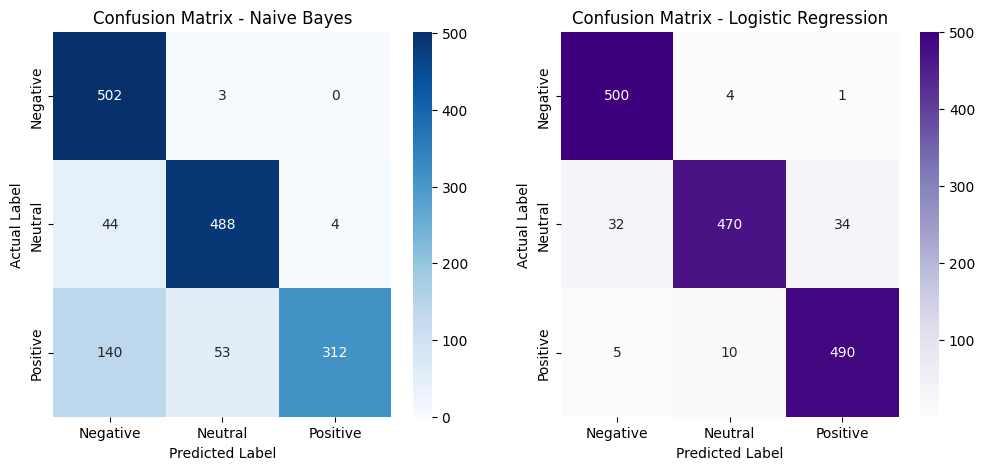

In [20]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Negative", "Neutral", "Positive"]

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title("Confusion Matrix - Naive Bayes")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Purples', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title("Confusion Matrix - Logistic Regression")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.show()

- **Naïve Bayes** misclassifies many positive reviews as negative, leading to lower accuracy for the positive sentiment category.  
- **Logistic Regression** performs better overall, but it slightly confuses neutral reviews with both negative and positive categories.

In [21]:
# saving processed data
data.to_csv("sentiment_analysis_results.csv", index=False)

In [22]:
# display sample result
print(data[['verified_reviews','cleaned_reviews','sentiment_score', 'sentiment_label']].head())

                                    verified_reviews  \
0                                      Love my Echo!   
1                                          Loved it!   
2  Sometimes while playing a game, you can answer...   
3  I have had a lot of fun with this thing. My 4 ...   
4                                              Music   

                                     cleaned_reviews  sentiment_score  \
0                                       love my echo           0.6369   
1                                           loved it           0.5994   
2  sometimes while playing a game you can answer ...          -0.1280   
3  i have had a lot of fun with this thing my  yr...           0.9169   
4                                              music           0.0000   

  sentiment_label  
0        Positive  
1        Positive  
2        Negative  
3        Positive  
4         Neutral  


### Sales prediction

In [23]:
df = pd.read_csv('sentiment_analysis_results.csv')
df.head()

,rating,date,variation,verified_reviews,feedback,cleaned_reviews,sentiment_score,sentiment_label,label
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,love my echo,0.6369,Positive,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,loved it,0.5994,Positive,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,sometimes while playing a game you can answer ...,-0.1280,Negative,0
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,i have had a lot of fun with this thing my yr...,0.9169,Positive,1
4,5,31-Jul-18,Charcoal Fabric,Music,1,music,0.0000,Neutral,2


In [66]:
# feature engineering. creating proxy for sales based on sentiment & feedback
df['sales_estimate'] = df['feedback'] * (df['rating'] + df['sentiment_score'])

In [67]:
# aggregate data by date
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%y')
df = df.groupby('date').agg({'sales_estimate':'sum', 'sentiment_score': 'mean', 'rating': 'mean', 'label': 'count'}).reset_index()
df.rename(columns={'label': 'review_count'}, inplace=True)

In [68]:
# train-test split
X = df[['sentiment_score', 'rating', 'review_count']]
y = df['sales_estimate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
# train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [71]:
y_pred = model.predict(X_test)

In [72]:
# model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 103.00
Mean Squared Error: 157533.70
R2 Score: 0.54


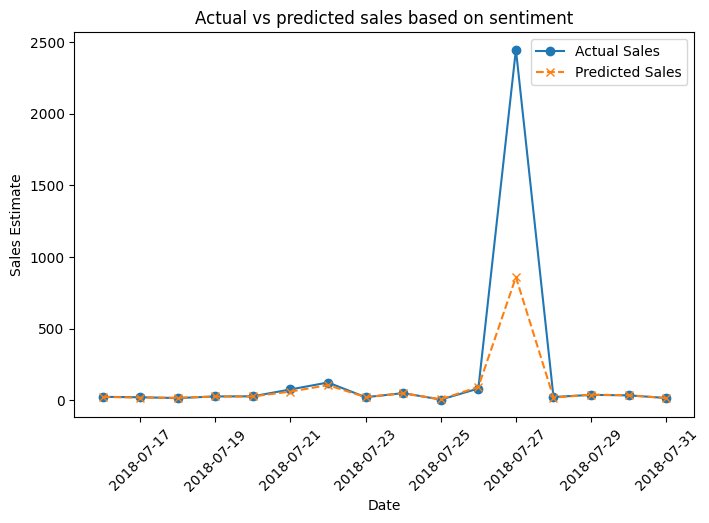

In [73]:
#plot predictions
plt.figure(figsize=(8,5))
plt.plot(df['date'][-len(y_test):], y_test, label='Actual Sales', marker='o')
plt.plot(df['date'][-len(y_test):], y_pred, label='Predicted Sales', linestyle='dashed',marker='x')
plt.xlabel('Date')
plt.ylabel('Sales Estimate')
plt.legend()
plt.title('Actual vs predicted sales based on sentiment')
plt.xticks(rotation=45)
plt.show()

- The spikes or drops in sales that aren't predicted well could mean external events like discounts or trends are affecting purchases.

In [74]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [75]:
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

C:\Users\Prachi\AppData\Local\Temp\ipykernel_6616\3717916315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['sentiment_label'], palette="Set1")


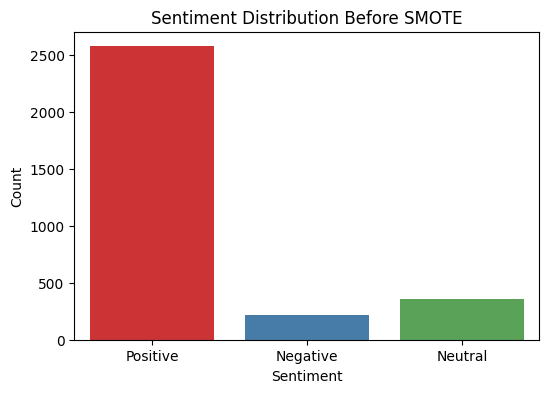

C:\Users\Prachi\AppData\Local\Temp\ipykernel_6616\3717916315.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="Set1")


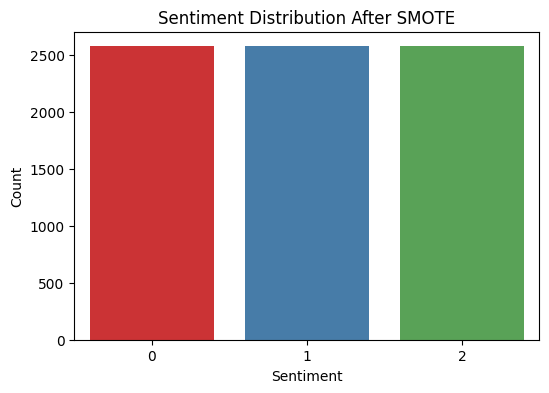

In [93]:
import seaborn as sns

# Before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=data['sentiment_label'], palette="Set1")
plt.title("Sentiment Distribution Before SMOTE")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# After SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette="Set1")
plt.title("Sentiment Distribution After SMOTE")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


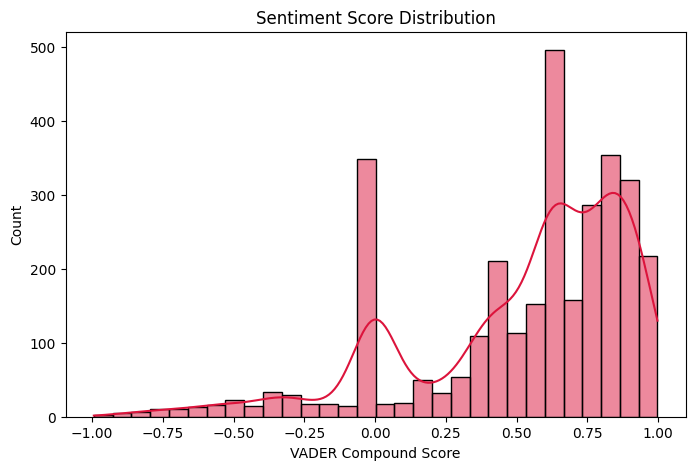

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(data['sentiment_score'], bins=30, kde=True, color="crimson")
plt.title("Sentiment Score Distribution")
plt.xlabel("VADER Compound Score")
plt.ylabel("Count")
plt.show()


- The histogram shows that **most sentiment scores are concentrated around positive values (0.5 to 1), with a significant peak at neutral (0), and fewer negative sentiment scores,** indicating that the majority of the reviews have a positive tone.

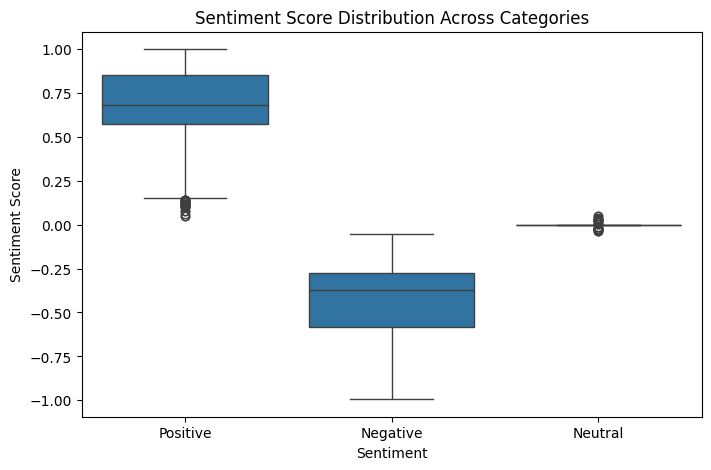

In [94]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['sentiment_label'], y=data['sentiment_score'])
plt.title("Sentiment Score Distribution Across Categories")
plt.xlabel("Sentiment")
plt.ylabel("Sentiment Score")
plt.show()


- The box plot shows that **positive sentiment scores are mostly concentrated between 0.5 and 1, negative sentiment scores range between -1 and 0, and neutral sentiment scores are tightly clustered around 0,** confirming a clear distinction in sentiment classification.

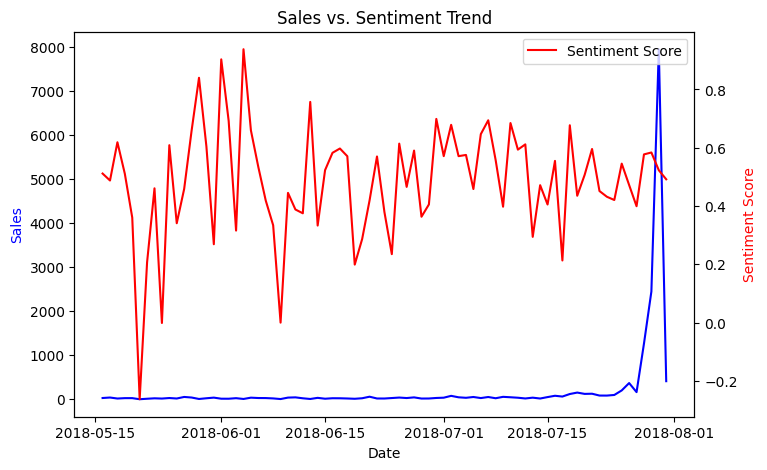

In [77]:
# sales vs sentiment trend
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(df['date'], df['sales_estimate'], color='blue', label='Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['sentiment_score'], color='red', label='Sentiment Score')
ax2.set_ylabel('Sentiment Score', color='red')

plt.title('Sales vs. Sentiment Trend')
plt.legend()
plt.show()

- Sales stay low and steady for most of the time but suddenly spike at the end, possibly due to a promotion or seasonal demand.
- Sentiment scores fluctuate a lot but mostly stay positive, though they don’t seem to impact sales much until the final surge.

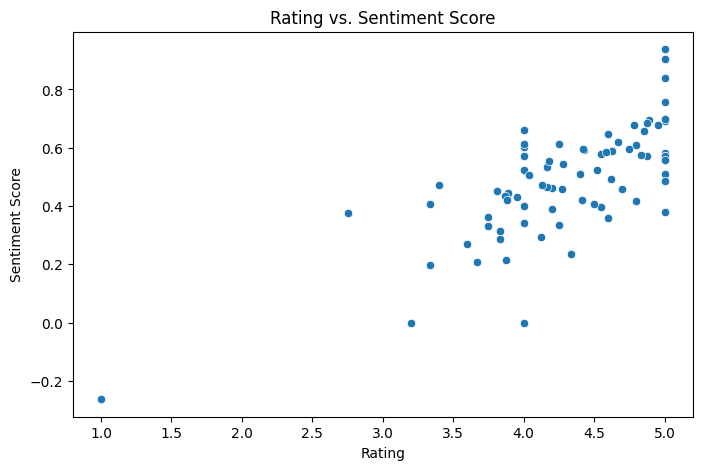

In [78]:
# rating vc sentiment score
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['rating'], y=df['sentiment_score'])
plt.title('Rating vs. Sentiment Score')
plt.xlabel('Rating')
plt.ylabel('Sentiment Score')
plt.show()

- Higher ratings generally have higher sentiment scores, showing a positive relationship between the two.
- A few lower ratings (like 1-star) still have slightly positive sentiment, possibly due to mixed reviews.

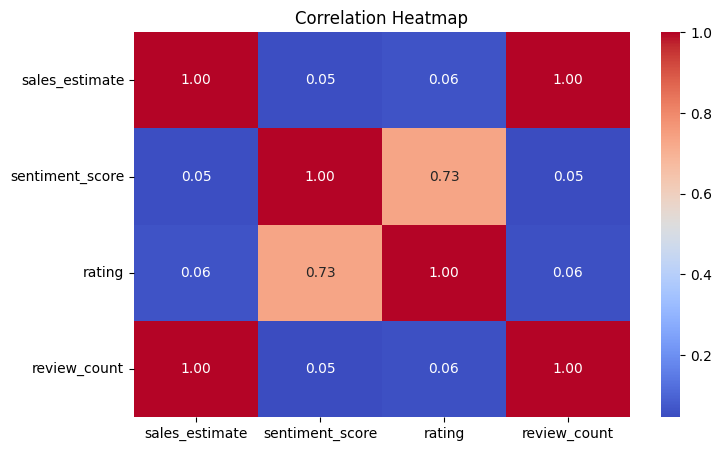

In [79]:
# correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['sales_estimate', 'sentiment_score', 'rating', 'review_count']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


- The correlation heatmap shows that **sentiment score and rating have a strong positive correlation (0.73),** while **sales estimate has almost no correlation with sentiment score, rating, or review count,** indicating that sentiment alone may not be a strong predictor of sales.

In [27]:
def predict_sentiment(review, model, vectorizer):
    # Preprocess the input review
    review_cleaned = re.sub(r'[^a-zA-Z]', ' ', review).lower()  # Basic text cleaning
    review_vectorized = vectorizer.transform([review_cleaned])  # Transform using TF-IDF
    
    # Predict sentiment
    prediction = model.predict(review_vectorized)[0]  # Get predicted label
    
    # Map prediction to sentiment label
    sentiment_mapping = {1: "Positive", 0: "Negative", 2: "Neutral"}
    return sentiment_mapping[prediction]

# Example usage
new_review = ""
predicted_sentiment = predict_sentiment(new_review, lr_model, vectorizer)  # Using Logistic Regression
print("Predicted Sentiment:", predicted_sentiment)


Predicted Sentiment: Neutral
